# Housing Price Prediction - by Horia Danciu

In [46]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import optuna

import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.model_selection import cross_val_score, KFold
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [47]:
# Importing data and understanding columns
df_test = pd.read_csv("Data/test.csv")
df = pd.read_csv("Data/train.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [48]:
test_ids = df_test["Id"].copy()
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


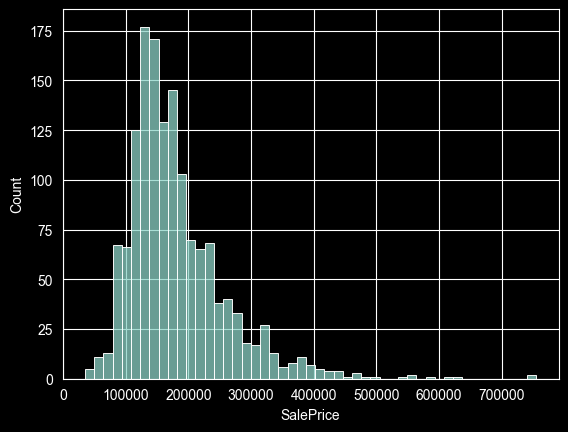

In [49]:
# Is target variable skewed?
sns.histplot(df.get('SalePrice'))
plt.show()

Target dependent variable "SalePrice" is right-skewed. So, I will perform a log-normal transformation on this feature.

In [50]:
# Testing out missing data for each column
df["GarageYrBlt"].value_counts(dropna=False)
#Latest

GarageYrBlt
NaN       81
2005.0    65
2006.0    59
2004.0    53
2003.0    50
          ..
1900.0     1
1927.0     1
1906.0     1
1908.0     1
1933.0     1
Name: count, Length: 98, dtype: int64

In [51]:
# Data Cleaning

df_clean = df.copy()
df_test_clean = df_test.copy()

df_clean["LotFrontage"] = df["LotFrontage"].fillna(0)
df_clean["Alley"] = df["Alley"].fillna("No Alley")
df_clean["PoolQC"] = df["PoolQC"].fillna("No Pool")
df_clean["Fence"] = df["Fence"].fillna("No Fence")
df_clean["FireplaceQu"] = df["FireplaceQu"].fillna("No Fireplace")
df_clean["MiscFeature"] = df["MiscFeature"].fillna("None")
df_clean["BsmtQual"] = df["BsmtQual"].fillna("No Basement")
df_clean["BsmtCond"] = df["BsmtCond"].fillna("No Basement")
df_clean["BsmtExposure"] = df["BsmtExposure"].fillna("No Basement")
df_clean["BsmtFinType1"] = df["BsmtFinType1"].fillna("No Basement")
df_clean["BsmtFinType2"] = df["BsmtFinType2"].fillna("No Basement")
df_clean["GarageType"] = df["GarageType"].fillna("No Garage")
df_clean["GarageFinish"] = df["GarageFinish"].fillna("No Garage")
df_clean["GarageQual"] = df["GarageQual"].fillna("No Garage")
df_clean["GarageCond"] = df["GarageCond"].fillna("No Garage")
df_clean["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)
df_clean["MasVnrType"] = df["MasVnrType"].fillna("None")
df_clean["MasVnrArea"] = df["MasVnrArea"].fillna(0)
df_clean['GarageYrBlt'] = df_clean["GarageYrBlt"].replace(2207, 2007)
df_clean["GarageYrBlt"] = df_clean["GarageYrBlt"].astype(int)
df_clean["Electrical"] = df["Electrical"].fillna("SBrkr")


df_test_clean["LotFrontage"] = df_test["LotFrontage"].fillna(0)
df_test_clean["Alley"] = df_test["Alley"].fillna("No Alley")
df_test_clean["PoolQC"] = df_test["PoolQC"].fillna("No Pool")
df_test_clean["Fence"] = df_test["Fence"].fillna("No Fence")
df_test_clean["FireplaceQu"] = df_test["FireplaceQu"].fillna("No Fireplace")
df_test_clean["MiscFeature"] = df_test["MiscFeature"].fillna("None")
df_test_clean["BsmtQual"] = df_test["BsmtQual"].fillna("No Basement")
df_test_clean["BsmtCond"] = df_test["BsmtCond"].fillna("No Basement")
df_test_clean["BsmtExposure"] = df_test["BsmtExposure"].fillna("No Basement")
df_test_clean["BsmtFinType1"] = df_test["BsmtFinType1"].fillna("No Basement")
df_test_clean["BsmtFinType2"] = df_test["BsmtFinType2"].fillna("No Basement")
df_test_clean["GarageType"] = df_test["GarageType"].fillna("No Garage")
df_test_clean["GarageFinish"] = df_test["GarageFinish"].fillna("No Garage")
df_test_clean["GarageQual"] = df_test["GarageQual"].fillna("No Garage")
df_test_clean["GarageCond"] = df_test["GarageCond"].fillna("No Garage")
df_test_clean["GarageYrBlt"] = df_test["GarageYrBlt"].fillna(0)
df_test_clean["MasVnrType"] = df_test["MasVnrType"].fillna("None")
df_test_clean["MasVnrArea"] = df_test["MasVnrArea"].fillna(0)
df_test_clean["GarageYrBlt"] = df_test_clean["GarageYrBlt"].replace(2207, 2007)
df_test_clean["GarageYrBlt"] = df_test_clean["GarageYrBlt"].astype(int)
df_test_clean["Electrical"] = df_test["Electrical"].fillna("SBrkr")




df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          1460 non-null   str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

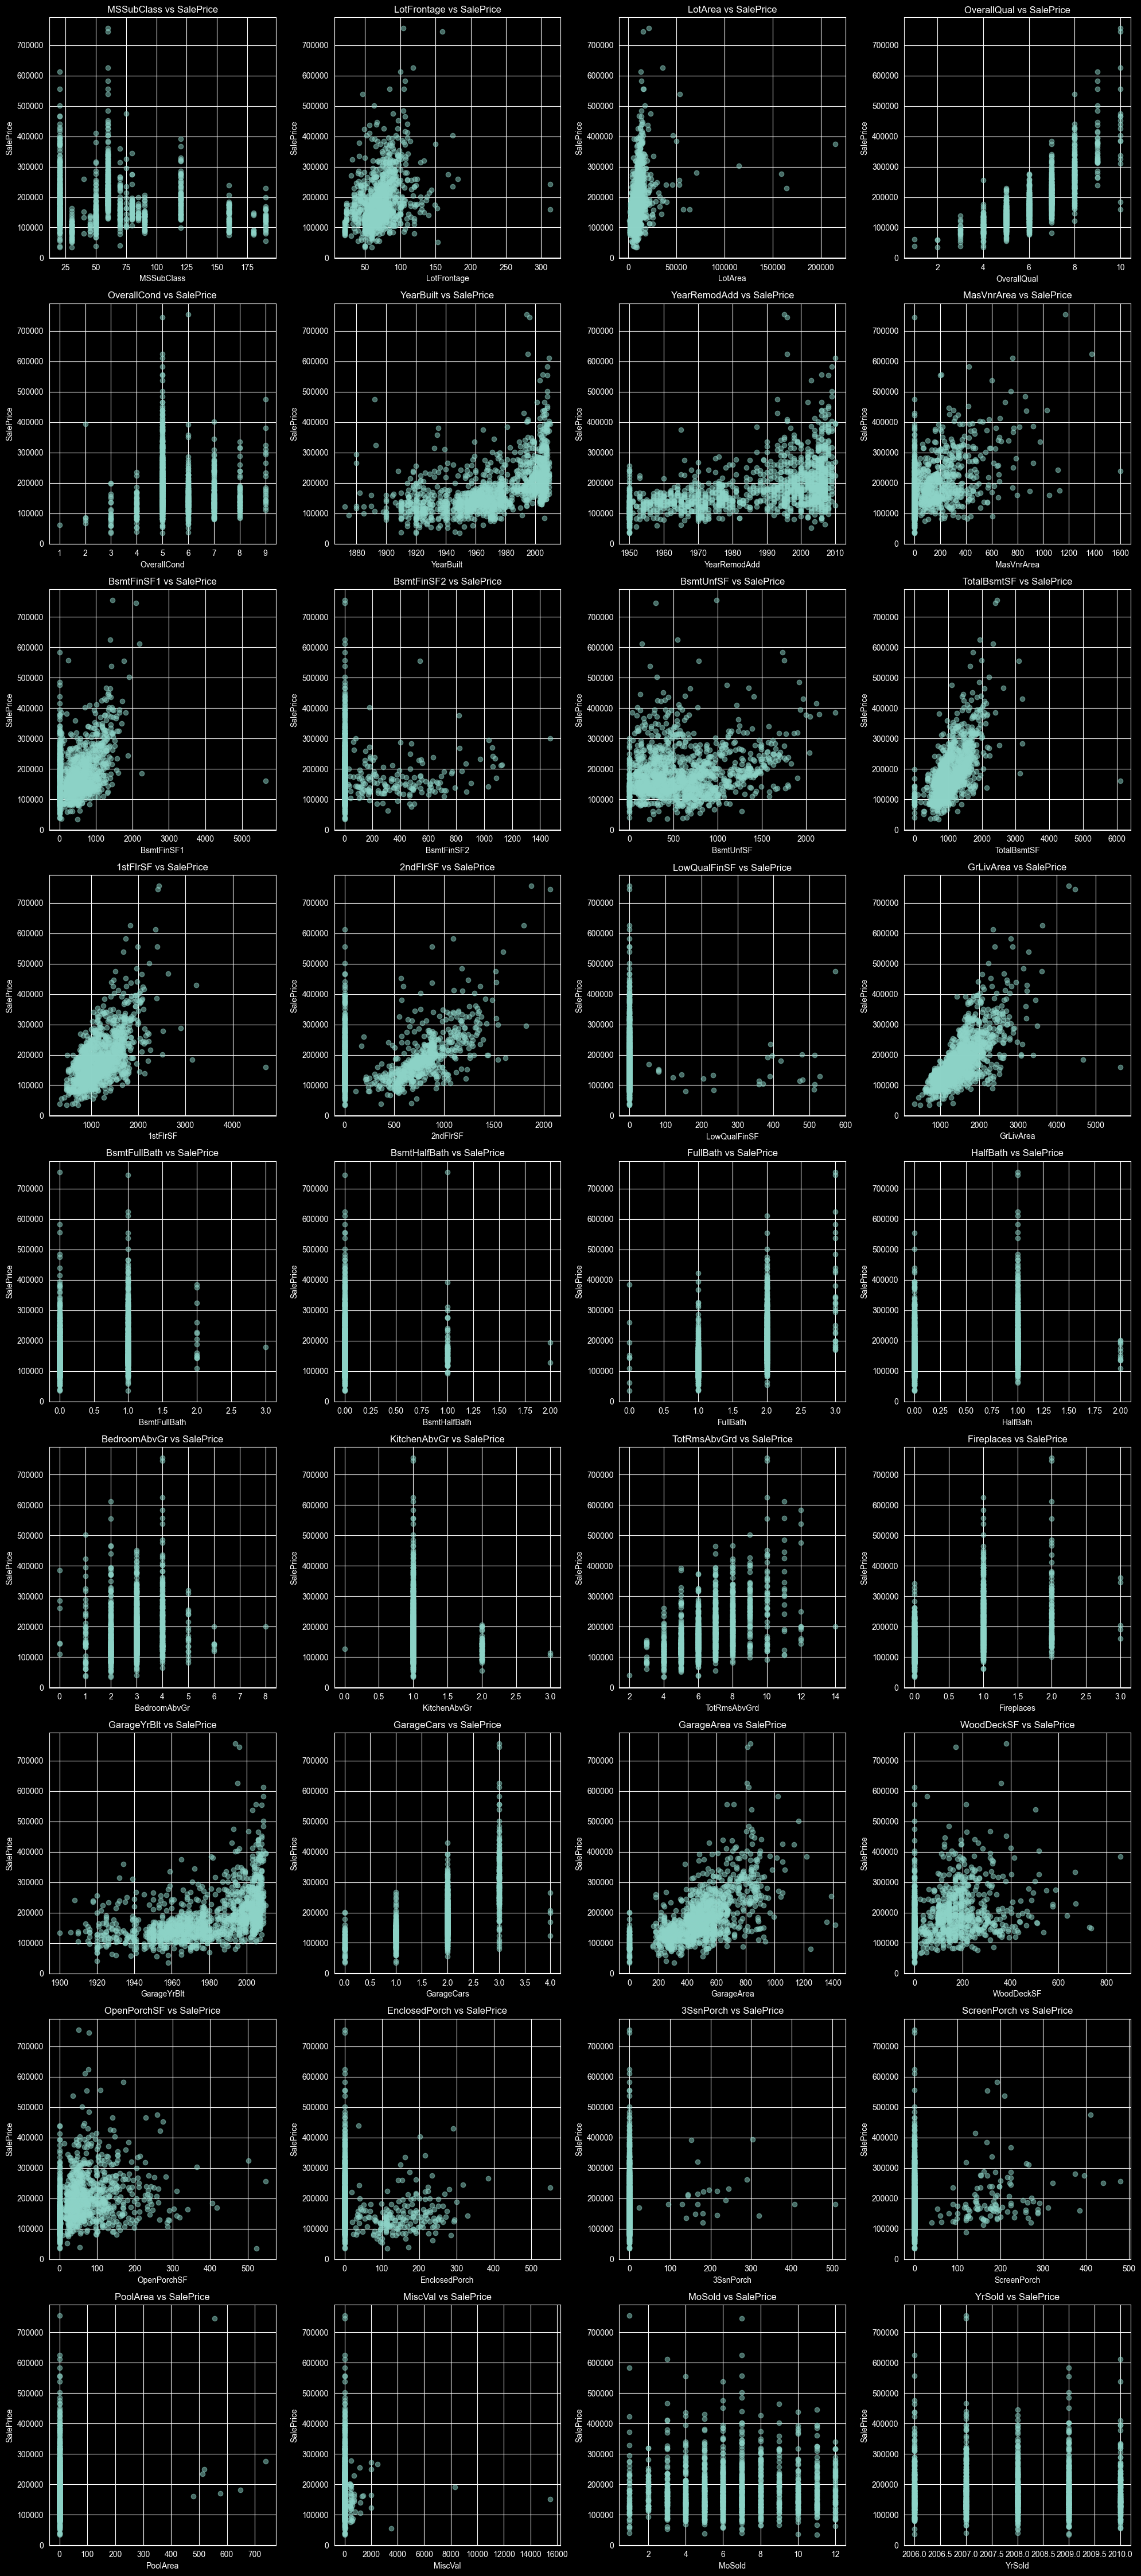

In [52]:
# Plot all numeric features against SalePrice
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('SalePrice')
numeric_cols.remove('Id')

# Create subplots
import math
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / 4)  # 4 plots per row

fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].scatter(df[col], df['SalePrice'], alpha=0.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{col} vs SalePrice')

# Hide unused subplots
for i in range(len(numeric_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

As we can see above, there are outliers in our numerical features. I will not delete the rows containing outliers because it might destroy some important data.

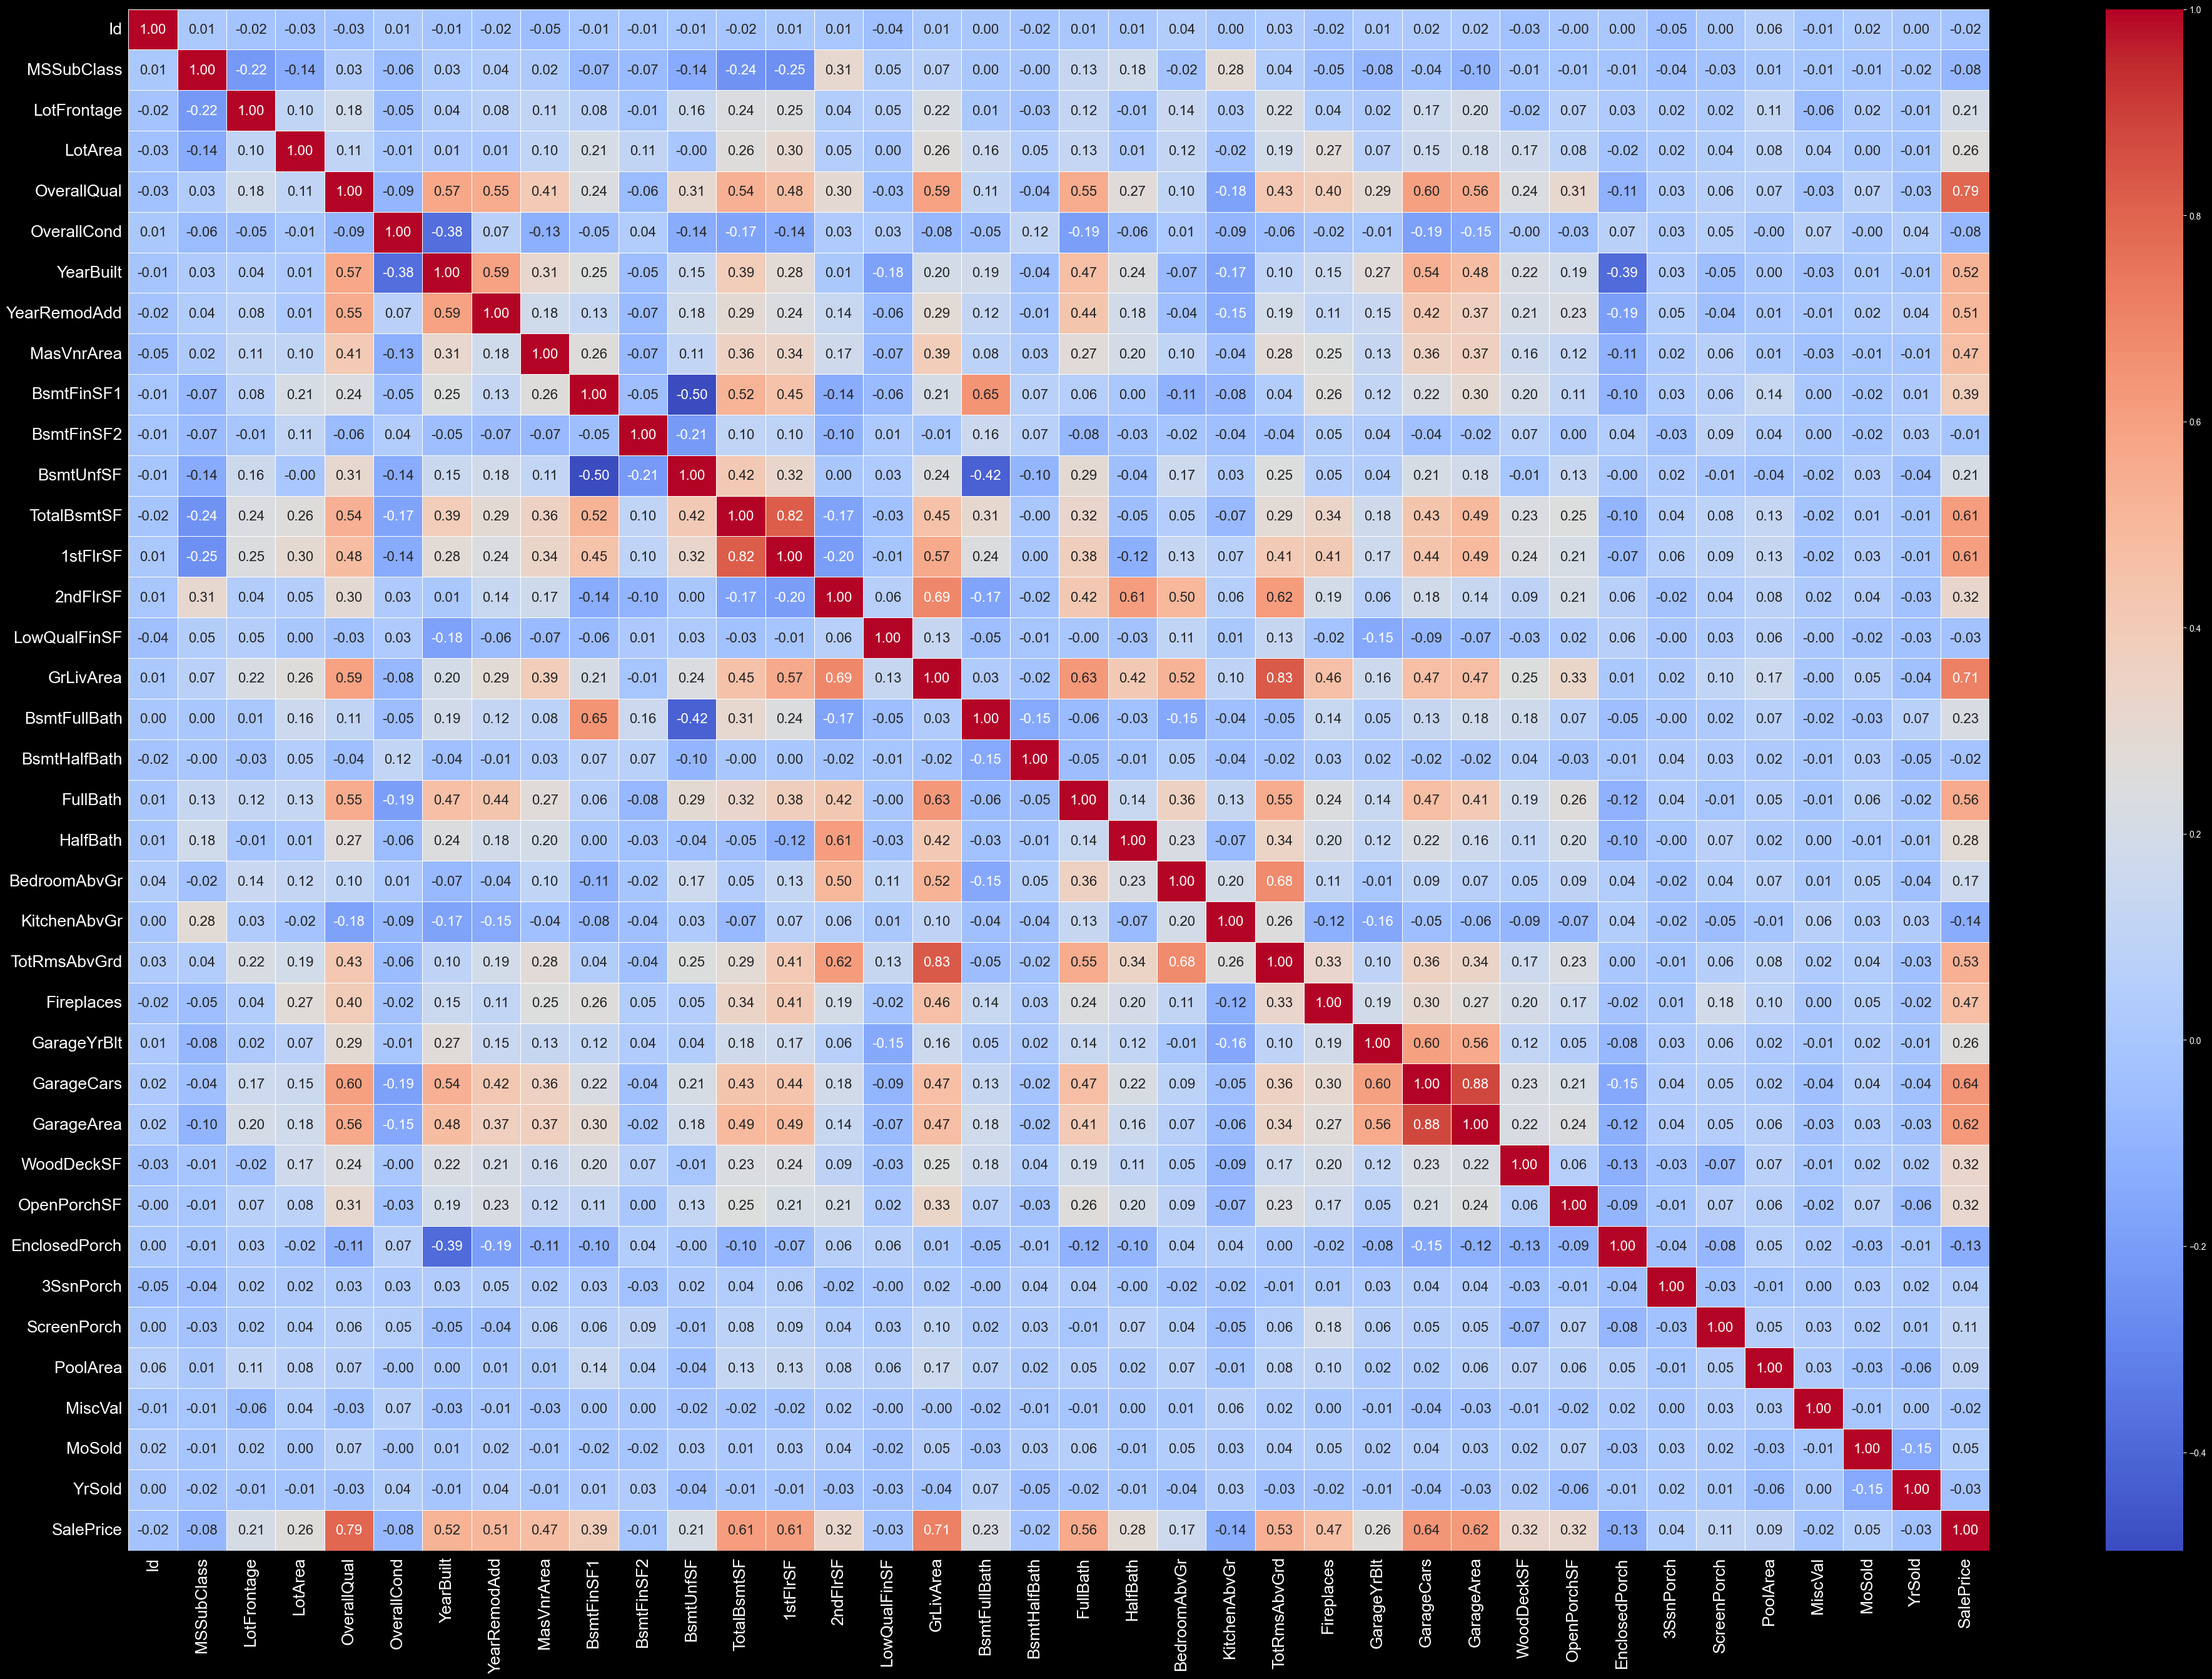

In [53]:
# Correlation Analysis
numeric_df = df_clean.select_dtypes(include=["int64", "float64"])
df_corr = numeric_df.corr()

plt.figure(figsize=(48, 32))

ax = sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt="0.2f", linewidths=0.5, annot_kws={"size": 16})

ax.set_xticklabels(ax.get_xticklabels(), fontsize=19)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=19)

plt.show()

In [54]:
# Converting absolute years to age at time of sale
df_clean["GarageYrBlt"] = df_clean["YrSold"] - df_clean["GarageYrBlt"] # This is going to be a problem because houses without a garage will have ex: 2007-0 = 2007 year old garages
df_clean["YearBuilt"] = df_clean["YrSold"] - df_clean["YearBuilt"]
df_clean["YearRemodAdd"] = df_clean["YrSold"] - df_clean["YearRemodAdd"]
df_clean.drop(["YrSold"], axis=1, inplace=True)
df_clean.drop(["MoSold"], axis=1, inplace=True)

df_test_clean["GarageYrBlt"] = df_test_clean["YrSold"] - df_test_clean["GarageYrBlt"]
df_test_clean["YearBuilt"] = df_test_clean["YrSold"] - df_test_clean["YearBuilt"]
df_test_clean["YearRemodAdd"] = df_test_clean["YrSold"] - df_test_clean["YearRemodAdd"]
df_test_clean.drop(["YrSold"], axis=1, inplace=True)
df_test_clean.drop(["MoSold"], axis=1, inplace=True)



In [55]:
# Comparing correlation before vs. after transformation
print(df['YearRemodAdd'].corr(df['SalePrice']))

print(df_clean['YearRemodAdd'].corr(df_clean['SalePrice']))

0.5071009671113865
-0.5090787380156293


In [56]:
# Aggregating correlated features reduces multicollinearity and simplifies the model without losing predictive power
df_clean["BsmtFinSF"] = df_clean["BsmtFinSF1"] + df_clean["BsmtFinSF2"]
df_clean["TotalFlrSF"] = df_clean["1stFlrSF"] + df_clean["2ndFlrSF"]

df_test_clean["BsmtFinSF"] = df_test_clean["BsmtFinSF1"] + df_test_clean["BsmtFinSF2"]
df_test_clean["TotalFlrSF"] = df_test_clean["1stFlrSF"] + df_test_clean["2ndFlrSF"]

df_clean.drop(['BsmtFinSF1'], axis=1, inplace=True)
df_clean.drop(['BsmtFinSF2'], axis=1, inplace=True)
df_clean.drop(['1stFlrSF'], axis=1, inplace=True)
df_clean.drop(['2ndFlrSF'], axis=1, inplace=True)
df_clean.drop(['TotalBsmtSF'], axis=1, inplace=True)

df_test_clean.drop(['BsmtFinSF1'], axis=1, inplace=True)
df_test_clean.drop(['BsmtFinSF2'], axis=1, inplace=True)
df_test_clean.drop(['1stFlrSF'], axis=1, inplace=True)
df_test_clean.drop(['2ndFlrSF'], axis=1, inplace=True)
df_test_clean.drop(['TotalBsmtSF'], axis=1, inplace=True)

In [57]:
# Aggregating correlated features reduces multicollinearity and simplifies the model without losing predictive power
df_clean["TotalBaths"] = df_clean["FullBath"] + (0.5 * df_clean["HalfBath"]) + df_clean["BsmtFullBath"] + (0.5 * df_clean["BsmtHalfBath"])

df_clean.drop(["FullBath"], axis=1, inplace=True)
df_clean.drop(["HalfBath"], axis=1, inplace=True)
df_clean.drop(["BsmtFullBath"], axis=1, inplace=True)
df_clean.drop(["BsmtHalfBath"], axis=1, inplace=True)

df_test_clean["TotalBaths"] = df_test_clean["FullBath"] + (0.5 * df_test_clean["HalfBath"]) + df_test_clean["BsmtFullBath"] + (0.5 * df_test_clean["BsmtHalfBath"])

df_test_clean.drop(["FullBath"], axis=1, inplace=True)
df_test_clean.drop(["HalfBath"], axis=1, inplace=True)
df_test_clean.drop(["BsmtFullBath"], axis=1, inplace=True)
df_test_clean.drop(["BsmtHalfBath"], axis=1, inplace=True)

In [58]:
# I engineer `GarageAreaPerCar` (garage square footage divided by car capacity) to capture garage efficiency.
# A large garage that fits few cars is different from a compact garage that fits many – this ratio preserves that distinction.
# Houses without a garage get `0`, maintaining the "no garage" signal.

df_clean["GarageAreaPerCar"] = df_clean["GarageArea"] / df_clean["GarageCars"]

df_clean["GarageAreaPerCar"] = df_clean["GarageAreaPerCar"].fillna(0)
df_clean.drop(["GarageArea"], axis=1, inplace=True)
df_clean.drop(["GarageCars"], axis=1, inplace=True)

df_test_clean["GarageAreaPerCar"] = df_test_clean["GarageArea"] / df_test_clean["GarageCars"]

df_test_clean["GarageAreaPerCar"] = df_test_clean["GarageAreaPerCar"].fillna(0)
df_test_clean.drop(["GarageArea"], axis=1, inplace=True)
df_test_clean.drop(["GarageCars"], axis=1, inplace=True)

In [59]:
# Systematically identifying skewed numeric features

num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols.remove("SalePrice")

skew_df = pd.DataFrame(num_cols, columns=["Feature"])

skew_df["Skew"] = skew_df["Feature"].apply(lambda feature: stats.skew(df_clean[feature]))

# Change Skew to a positive number
skew_df["Absolute Skew"] = skew_df["Skew"].apply(abs)

# Create true/false columns based on if Absolute Skew is >=0.5
skew_df["Skewed"] = skew_df["Absolute Skew"].apply(lambda x: True if x >= 0.5 else False)

skew_df

,Feature,Skew,Absolute Skew,Skewed
0,Id,0.000000,0.000000,False
1,MSSubClass,1.406210,1.406210,True
2,LotFrontage,0.267547,0.267547,False
3,LotArea,12.195142,12.195142,True
4,OverallQual,0.216721,0.216721,False
5,OverallCond,0.692355,0.692355,True
6,YearBuilt,0.608404,0.608404,True
7,YearRemodAdd,0.501973,0.501973,True
8,MasVnrArea,2.674865,2.674865,True
9,BsmtUnfSF,0.919323,0.919323,True


In [60]:
df_clean[num_cols].describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtUnfSF,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,BsmtFinSF,TotalFlrSF,TotalBaths,GarageAreaPerCar
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,57.623288,10516.828082,6.099315,5.575342,36.547945,22.950000,103.117123,567.240411,...,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,490.189041,1509.619178,2.210616,256.935274
std,421.610009,42.300571,34.664304,9981.264932,1.382997,1.112799,30.250152,20.640653,180.731373,441.866955,...,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,476.103307,521.163523,0.785399,87.957630
min,1.000000,20.000000,0.000000,1300.000000,1.000000,1.000000,0.000000,-1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,1.000000,0.000000
25%,365.750000,20.000000,42.000000,7553.500000,5.000000,5.000000,8.000000,4.000000,0.000000,223.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1123.750000,2.000000,225.333333
50%,730.500000,50.000000,63.000000,9478.500000,6.000000,5.000000,35.000000,14.000000,0.000000,477.500000,...,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,465.000000,1458.000000,2.000000,263.500000
75%,1095.250000,70.000000,79.000000,11601.500000,7.000000,6.000000,54.000000,41.000000,164.250000,808.000000,...,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,790.250000,1775.250000,2.500000,290.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,136.000000,60.000000,1600.000000,2336.000000,...,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,5644.000000,5642.000000,6.000000,924.000000


In [61]:
# Applying "log1p" transformation only to features flagged as skewed
for column in skew_df.query("Skewed == True")["Feature"].values:
    df_clean[column] = np.log1p(df_clean[column])
    df_test_clean[column] = np.log1p(df_test_clean[column])

In [62]:
# Separating numeric features from the target ("SalesPrice") and identifier ("Id")
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
num_cols = num_cols.drop("SalePrice")
num_cols = num_cols.drop("Id")

In [63]:
# Isolating all categorical features into a separate DataFrame before encoding
categorical_cols = df_clean.select_dtypes(include="object").columns

df_categorical = df_clean[categorical_cols].copy()

df_categorical

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,No Alley,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,No Pool,No Fence,None,WD,Normal
1,RL,Pave,No Alley,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,No Pool,No Fence,None,WD,Normal
2,RL,Pave,No Alley,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,No Pool,No Fence,None,WD,Normal
3,RL,Pave,No Alley,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,No Pool,No Fence,None,WD,Abnorml
4,RL,Pave,No Alley,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,No Pool,No Fence,None,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,No Alley,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,Attchd,RFn,TA,TA,Y,No Pool,No Fence,None,WD,Normal
1456,RL,Pave,No Alley,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Attchd,Unf,TA,TA,Y,No Pool,MnPrv,None,WD,Normal
1457,RL,Pave,No Alley,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,Attchd,RFn,TA,TA,Y,No Pool,GdPrv,Shed,WD,Normal
1458,RL,Pave,No Alley,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,No Pool,No Fence,None,WD,Normal


In [64]:
# Inspecting unique values in each ordinal feature before mapping
ordinal_1 = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu",
             "GarageQual", "GarageCond", "PoolQC"]

for col in ordinal_1:
    print(col, df_clean[col].unique())
    print()

ExterQual <StringArray>
['Gd', 'TA', 'Ex', 'Fa']
Length: 4, dtype: str

ExterCond <StringArray>
['TA', 'Gd', 'Fa', 'Po', 'Ex']
Length: 5, dtype: str

BsmtQual <StringArray>
['Gd', 'TA', 'Ex', 'No Basement', 'Fa']
Length: 5, dtype: str

BsmtCond <StringArray>
['TA', 'Gd', 'No Basement', 'Fa', 'Po']
Length: 5, dtype: str

HeatingQC <StringArray>
['Ex', 'Gd', 'TA', 'Fa', 'Po']
Length: 5, dtype: str

KitchenQual <StringArray>
['Gd', 'TA', 'Ex', 'Fa']
Length: 4, dtype: str

FireplaceQu <StringArray>
['No Fireplace', 'TA', 'Gd', 'Fa', 'Ex', 'Po']
Length: 6, dtype: str

GarageQual <StringArray>
['TA', 'Fa', 'Gd', 'No Garage', 'Ex', 'Po']
Length: 6, dtype: str

GarageCond <StringArray>
['TA', 'Fa', 'No Garage', 'Gd', 'Po', 'Ex']
Length: 6, dtype: str

PoolQC <StringArray>
['No Pool', 'Ex', 'Fa', 'Gd']
Length: 4, dtype: str



In [65]:
# Handling ordinal features with a conditional mapping strategy
missing_mapping = {
    "BsmtQual": "No Basement",
    "BsmtCond": "No Basement",
    "FireplaceQu": "No Fireplace",
    "GarageQual": "No Garage",
    "GarageCond": "No Garage",
    "PoolQC": "No Pool"
}


quality_mapping = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
quality_mapping_with_missing = {"No Basement": 0, "No Fireplace": 0, "No Garage": 0, "No Pool": 0,
                                "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}

for col in ordinal_1:
    if col in missing_mapping:
        missing_val = missing_mapping[col]

        if missing_val in df_clean[col].values:
            df_clean[col] = df_clean[col].map(quality_mapping_with_missing).fillna(0).astype("int")
        else:
            df_clean[col] = df_clean[col].map(quality_mapping).fillna(0).astype("int")

        if missing_val in df_test_clean[col].values:
            df_test_clean[col] = df_test_clean[col].map(quality_mapping_with_missing).fillna(0).astype("int")
        else:
            df_test_clean[col] = df_test_clean[col].map(quality_mapping).fillna(0).astype("int")
    else:
        df_clean[col] = df_clean[col].map(quality_mapping).fillna(0).astype("int")
        df_test_clean[col] = df_test_clean[col].map(quality_mapping).fillna(0).astype("int")


In [66]:
# Verifying unique values in each ordinal feature after mapping to confirm correct mapping
ordinal_1 = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu",
             "GarageQual", "GarageCond", "PoolQC"]

for col in ordinal_1:
    print(col, df_clean[col].unique())
    print()

ExterQual [4 3 5 2]

ExterCond [3 4 2 1 5]

BsmtQual [4 3 5 0 2]

BsmtCond [3 4 0 2 1]

HeatingQC [5 4 3 2 1]

KitchenQual [4 3 5 2]

FireplaceQu [0 3 4 2 5 1]

GarageQual [3 2 4 0 5 1]

GarageCond [3 2 0 4 1 5]

PoolQC [0 5 2 4]



In [67]:
# Applying custom ordinal mapping to 12 additional categorical features
ordinal_2 = ['LotShape', 'LandContour', 'LandSlope', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'Utilities', 'CentralAir', 'Functional', 'GarageFinish', 'PavedDrive', 'Fence']

mapping_dict = {
    'LotShape': {"None":0, "IR3":1, "IR2":2, "IR1":3, "Reg":4},
    'LandContour': {"None":0, "Low":1, "Bnk":2, "HLS":3, "Lvl":4},
    'LandSlope': {"None":0, "Sev":1, "Mod":2, "Gtl":3},
    'BsmtExposure': {"None":0, "No":1, "Mn":2, "Av":3, "Gd":4},
    'BsmtFinType1': {"None":0, "Unf":1, "LwQ":2, "Rec":3, "BLQ":4, "ALQ":5, "GLQ":6},
    'BsmtFinType2': {"None":0, "Unf":1, "LwQ":2, "Rec":3, "BLQ":4, "ALQ":5, "GLQ":6},
    'Utilities': {"None":0, "ELO":1, "NoSeWa":2, "NoSewr":3, "AllPub":4},
    'CentralAir': {"None":0, "N":1, "Y":2},
    'Functional': {"None":0, "Sal":1, "Sev":2, "Maj2":3, "Maj1":4, "Mod":5, "Min2":6, "Min1":7, "Typ":8},
    'GarageFinish': {"None":0, "Unf":1, "RFn":2, "Fin":3},
    'PavedDrive': {"None":0, "N":1, "P":2, "Y":3},
    'Fence': {"None":0, "MnWw":1, "GdWo":2, "MnPrv":3, "GdPrv":4}
}

# Apply to train and test
for col in ordinal_2:
    # Fill missing with 'None' first
    df_clean[col] = df_clean[col].fillna('None')
    df_test_clean[col] = df_test_clean[col].fillna('None')

    # Map and convert to int
    df_clean[col] = df_clean[col].map(mapping_dict[col]).fillna(0).astype('int')
    df_test_clean[col] = df_test_clean[col].map(mapping_dict[col]).fillna(0).astype('int')

In [68]:
# Inspecting that the labeling has been applied correctly
for col in ordinal_2:
    print(col, df_clean[col].unique())
    print()

LotShape [4 3 2 1]

LandContour [4 2 1 3]

LandSlope [3 2 1]

BsmtExposure [1 4 2 3 0]

BsmtFinType1 [6 5 1 3 4 0 2]

BsmtFinType2 [1 4 0 5 3 2 6]

Utilities [4 2]

CentralAir [2 1]

Functional [8 7 4 6 5 3 2]

GarageFinish [2 1 3 0]

PavedDrive [3 1 2]

Fence [0 3 2 4 1]



In [69]:
# Drop ordinal columns from the categorical DataFrame
remaining_cat_df = df_categorical.drop(columns=ordinal_1)
remaining_cat_df = df_categorical.drop(columns=ordinal_2)

# Get column names for one-hot encoding
ohe_ = remaining_cat_df.columns.tolist()

# One-hot encode those columns (from the original df, not df_categorical)
df_encoded = pd.get_dummies(df[ohe_], drop_first=True).astype(int)

# Drop original categorical columns and concatenate
df = pd.concat([df.drop(columns=ohe_), df_encoded], axis=1)

In [70]:
# Perform log transformation on SalePrice so it's less skewed
log_target = np.log(df_clean['SalePrice'])

df_clean.drop(['SalePrice'], axis=1, inplace=True)

In [71]:
# Define objective function for Optuna for catboost
def objective_cat(trial):
    # Define hyperparameters to optimize
    catboost_params = {
        'iterations': trial.suggest_int('iterations', 1000, 8000),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.005, 0.08),
        'depth': trial.suggest_int('depth', 3, 7),
        'eval_metric': 'RMSE',
    }

#   Initialize models with suggested parameters
    catboost_model = CatBoostRegressor(**catboost_params, verbose=0)

#   Calculate RMSE
    kf = KFold(n_splits=10)
    catboost_rmse = np.exp(np.sqrt(-cross_val_score(catboost_model, df_clean, log_target, scoring='neg_mean_squared_error', cv=kf)))

#   Return average RMSE
    return np.mean(catboost_rmse)

In [72]:
# Define objective function for Optuna for xgboost
def objective_xgb(trial):
    # Define hyperparameters to optimize
     xgboost_params = {
         'n_estimators': trial.suggest_int('n_estimators', 1000, 8000),
         'learning_rate': trial.suggest_loguniform('learning_rate', 0.005, 0.08),
         'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.2, 0.6),
         'subsample': trial.suggest_uniform('subsample', 0.4, 0.8),
         'min_child_weight': trial.suggest_int('min_child_weight', 2, 5),
     }

     # Initialize models with suggested parameters
     xgb_model = XGBRegressor(**xgboost_params, verbosity=0)

     # Calculate RMSE
     kf = KFold(n_splits=10)
     xgb_rmse = np.exp(np.sqrt(-cross_val_score(xgb_model, df_clean, log_target, scoring='neg_mean_squared_error', cv=kf)))

     # Return average RMSE
     return np.mean(xgb_rmse)

In [73]:
# I one-hot encode all remaining categorical features and align test set columns with training set
df_clean = pd.get_dummies(df_clean, drop_first=True)

df_test_clean = pd.get_dummies(df_test_clean, drop_first=True)
df_test_clean = df_test_clean.reindex(columns=df_clean.columns, fill_value=0)


df_clean = df_clean.replace([np.inf, -np.inf], np.nan).dropna()
log_target = log_target.loc[df_clean.index]

In [74]:
# Optimize hyperparameters catboost
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials = 20)

[I 2026-04-15 10:14:49,814] A new study created in memory with name: no-name-fd3dec46-2698-4511-86cd-7fc0d70f460e
[I 2026-04-15 10:15:53,912] Trial 0 finished with value: 1.127497949195359 and parameters: {'iterations': 3904, 'learning_rate': 0.023437614208995282, 'depth': 7}. Best is trial 0 with value: 1.127497949195359.
[I 2026-04-15 10:16:26,579] Trial 1 finished with value: 1.129175305313284 and parameters: {'iterations': 5069, 'learning_rate': 0.05786439414566518, 'depth': 5}. Best is trial 0 with value: 1.127497949195359.
[I 2026-04-15 10:17:58,634] Trial 2 finished with value: 1.1271134986571851 and parameters: {'iterations': 5366, 'learning_rate': 0.008810388107904287, 'depth': 7}. Best is trial 2 with value: 1.1271134986571851.
[I 2026-04-15 10:18:57,289] Trial 3 finished with value: 1.1273293219340332 and parameters: {'iterations': 5612, 'learning_rate': 0.029838726991824473, 'depth': 6}. Best is trial 2 with value: 1.1271134986571851.
[I 2026-04-15 10:19:17,747] Trial 4 fin

In [75]:
# Optimize hyperparameters XGBoost
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials = 15)

[I 2026-04-15 10:23:54,449] A new study created in memory with name: no-name-f9d7e0b6-cab4-4029-a239-769e66545bd5
[I 2026-04-15 10:25:02,489] Trial 0 finished with value: 1.1328554066228482 and parameters: {'n_estimators': 5085, 'learning_rate': 0.05059216334399871, 'colsample_bytree': 0.5467989203355739, 'subsample': 0.6244298968798059, 'min_child_weight': 5}. Best is trial 0 with value: 1.1328554066228482.
[I 2026-04-15 10:26:46,427] Trial 1 finished with value: 1.1301361818227087 and parameters: {'n_estimators': 5003, 'learning_rate': 0.022625160498880508, 'colsample_bytree': 0.20522415446580952, 'subsample': 0.6700719155037964, 'min_child_weight': 5}. Best is trial 1 with value: 1.1301361818227087.
[I 2026-04-15 10:27:24,543] Trial 2 finished with value: 1.131679490803923 and parameters: {'n_estimators': 1808, 'learning_rate': 0.029839869517471484, 'colsample_bytree': 0.5744005459912439, 'subsample': 0.6489580666919641, 'min_child_weight': 3}. Best is trial 1 with value: 1.13013618

In [76]:
# Get best parameters for each model
best_params_cat = study_cat.best_params
best_params_xgb = study_xgb.best_params

In [77]:
best_params_cat

{'iterations': 3912, 'learning_rate': 0.018231029663699258, 'depth': 5}

In [78]:
study_cat.best_value

1.126203369823397

In [79]:
best_params_xgb

{'n_estimators': 6060,
 'learning_rate': 0.011217287120470706,
 'colsample_bytree': 0.21947124944122234,
 'subsample': 0.7260241418373082,
 'min_child_weight': 5}

In [80]:
study_xgb.best_value

1.1283390817361147

In [89]:
best_params_cat = {
    'iterations': 3912,
    'learning_rate': 0.018231029663699258,
    'depth': 5,
    'eval_metric':'RMSE',
}

best_params_xgb = {
    'n_estimators': 6060,
    'learning_rate': 0.011217287120470706,
    'colsample_bytree': 0.21947124944122234,
    'subsample': 0.7260241418373082,
    'min_child_weight': 2,
}

In [90]:
# Creating CatBoost Model
catboost_model = CatBoostRegressor(**best_params_cat, verbose=0)
catboost_model.fit(df_clean, log_target)

CatBoostRegressor(depth=5, eval_metric='RMSE', iterations=3912, learning_rate=0.018231029663699258, loss_function='RMSE', verbose=0)

In [91]:
# Creating XGBoost Model
xgb_model = XGBRegressor(**best_params_xgb, verbosity=0)
xgb_model.fit(df_clean, log_target)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.21947124944122234
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegr

In [92]:
# Evaluated models using 10-fold cross-validation on log-transformed target, and exponentiate RMSE back to riginal price scale
kf = KFold(n_splits=10)
catboost_rmse = np.exp(np.sqrt(-cross_val_score(catboost_model, df_clean, log_target, scoring='neg_mean_squared_error', cv=kf)))
xgb_rmse = np.exp(np.sqrt(-cross_val_score(xgb_model, df_clean, log_target, scoring='neg_mean_squared_error', cv=kf)))

In [93]:
# CatBoost performs slightly better, so I give it a higher weight (80%) in the final ensemble
print("CatBoost:", np.mean(catboost_rmse))
print("XGBoost", np.mean(xgb_rmse))

CatBoost: 1.126203369823397
XGBoost 1.1286758810982183


In [94]:
final_predictions = (
        0.80 * np.exp(catboost_model.predict(df_test_clean)) +
        0.20 * np.exp(xgb_model.predict(df_test_clean))
)

In [95]:
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": final_predictions
})

submission.to_csv("submission.csv", index=False)
submission

,Id,SalePrice
0,1461,113564.422996
1,1462,162371.160585
2,1463,181007.463092
3,1464,191097.451804
4,1465,187779.306920
...,...,...
1454,2915,81339.587075
1455,2916,79766.872971
1456,2917,156521.527045
1457,2918,112698.470728
